# 📊 Tarea 3: Regresión Lineal para Estimar TotalCharges

**Problema:** Una empresa de telecomunicaciones desea estimar cuánto dinero generará un cliente (`TotalCharges`) usando estas variables:
- Permanencia del cliente (`tenure`)
- Cargos mensuales (`MonthlyCharges`)
- Tipo de contrato (`Contract`)
- Tipo de servicio de internet (`InternetService`)

La variable objetivo será: **`TotalCharges`**.

---

Este notebook documenta paso a paso el flujo de regresión lineal, mostrando cada etapa con explicaciones, visualizaciones y mensajes destacados.

## 📦 1. Importación de librerías
Importamos todas las librerías necesarias para análisis, visualización y modelado de datos.

In [48]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown

def mostrar_titulo(texto, icono="🔹"):
    display(Markdown(f"\n### {icono} {texto}"))

mostrar_titulo("Librerías importadas correctamente", "📦")


### 📦 Librerías importadas correctamente

## 📂 2. Carga del dataset
Cargamos el archivo CSV con los datos de clientes y mostramos una vista rápida de las últimas filas para verificar la carga.

In [49]:
# Carga del dataset
ruta_csv = "../domingo/telecom_churn.csv"
datos = pd.read_csv(ruta_csv)
mostrar_titulo("Dataset cargado correctamente", "📂")
display(datos.head())


### 📂 Dataset cargado correctamente

,gender,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,Male,4,34.69,102.71,Two year,Fiber optic,1
1,Male,55,56.56,3084.07,Month-to-month,DSL,0
2,Male,70,56.95,3964.32,One year,DSL,0
3,Male,55,39.33,2208.87,One year,Fiber optic,0
4,Male,49,109.32,5367.05,Month-to-month,Fiber optic,0


## 🔍 3. Exploración inicial
Exploramos la estructura, tipos de datos, estadísticas y valores nulos del dataset para entender su estado antes del preprocesamiento.

In [50]:
mostrar_titulo("Información general del dataset", "🔍")
print("\nINFORMACIÓN DEL DATASET\n" + "="*40)
print(datos.info())

mostrar_titulo("Estadísticas descriptivas", "📊")
display(datos.describe())

mostrar_titulo("Valores nulos por campo", "⚠️")
print(datos.isnull().sum())


### 🔍 Información general del dataset


INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1200 non-null   str    
 1   tenure           1200 non-null   int64  
 2   MonthlyCharges   1200 non-null   float64
 3   TotalCharges     1200 non-null   float64
 4   Contract         1200 non-null   str    
 5   InternetService  1200 non-null   str    
 6   Churn            1200 non-null   int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 65.8 KB
None



### 📊 Estadísticas descriptivas

,tenure,MonthlyCharges,TotalCharges,Churn
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.875000,64.221175,2368.704300,0.408333
std,20.645934,23.471789,1641.425281,0.491730
min,1.000000,20.040000,7.570000,0.000000
25%,18.000000,46.262500,1035.030000,0.000000
50%,37.000000,63.765000,2078.625000,0.000000
75%,55.250000,79.122500,3407.220000,1.000000
max,72.000000,120.000000,8418.100000,1.000000



### ⚠️ Valores nulos por campo

gender             0
tenure             0
MonthlyCharges     0
TotalCharges       0
Contract           0
InternetService    0
Churn              0
dtype: int64


## 🛠️ 4. Preprocesamiento de datos
Realizamos limpieza y transformación de los datos:
- Eliminación de valores nulos
- Eliminación de duplicados
- Conversión de variables categóricas a numéricas

In [51]:
# Aseguramos que TotalCharges sea numérica
mostrar_titulo("Conversión de TotalCharges a numérico", "🔢")
datos["TotalCharges"] = pd.to_numeric(datos["TotalCharges"], errors="coerce")

# Eliminamos valores nulos
datos = datos.dropna()
mostrar_titulo("Valores nulos eliminados", "🧹")

# Eliminamos duplicados
datos = datos.drop_duplicates()
mostrar_titulo("Duplicados eliminados", "🗑️")

# Codificamos variables categóricas
encoder = LabelEncoder()
datos["gender"] = encoder.fit_transform(datos["gender"])
datos["Contract"] = encoder.fit_transform(datos["Contract"])
datos["InternetService"] = encoder.fit_transform(datos["InternetService"])
mostrar_titulo("Variables categóricas codificadas", "🔄")
display(datos.head())


### 🔢 Conversión de TotalCharges a numérico


### 🧹 Valores nulos eliminados


### 🗑️ Duplicados eliminados


### 🔄 Variables categóricas codificadas

,gender,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
0,1,4,34.69,102.71,2,1,1
1,1,55,56.56,3084.07,0,0,0
2,1,70,56.95,3964.32,1,0,0
3,1,55,39.33,2208.87,1,1,0
4,1,49,109.32,5367.05,0,1,0


## 🎯 5. Selección de variables
Definimos las variables independientes (X) y la variable dependiente (y) para el modelo de regresión.

In [52]:
# Variables independientes (X)
X = datos[["tenure", "MonthlyCharges", "Contract", "InternetService"]]
mostrar_titulo("Variables independientes definidas", "🎯")
print(f"{X}")

# Variable dependiente (y)
y = datos["TotalCharges"]
mostrar_titulo("Variable dependiente definida", "🎯")
print(f"{y}")


### 🎯 Variables independientes definidas

      tenure  MonthlyCharges  Contract  InternetService
0          4           34.69         2                1
1         55           56.56         0                0
2         70           56.95         1                0
3         55           39.33         1                1
4         49          109.32         0                1
...      ...             ...       ...              ...
1195      54           36.29         1                0
1196      29           65.61         0                2
1197      62           68.44         2                1
1198      47           75.05         0                0
1199      25           74.76         2                2

[1200 rows x 4 columns]



### 🎯 Variable dependiente definida

0        102.71
1       3084.07
2       3964.32
3       2208.87
4       5367.05
         ...   
1195    1997.27
1196    1875.72
1197    4230.87
1198    3532.82
1199    1854.99
Name: TotalCharges, Length: 1200, dtype: float64


## ✂️ 6. División de datos
Dividimos el dataset en conjunto de entrenamiento (80%) y prueba (20%) para evaluar el modelo de forma justa.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
mostrar_titulo("División 80% entrenamiento, 20% prueba", "✂️")
print("===== TAMAÑO DE LOS DATOS =====\n")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


### ✂️ División 80% entrenamiento, 20% prueba

===== TAMAÑO DE LOS DATOS =====

X_train: (960, 4)
X_test : (240, 4)
y_train: (960,)
y_test : (240,)


## 📏 7. Normalización de datos
Normalizamos las variables independientes para mejorar el desempeño y la estabilidad del modelo de regresión.

In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
mostrar_titulo("Normalización realizada", "📏")


### 📏 Normalización realizada

## 🤖 8. Creación y entrenamiento del modelo
Creamos el modelo de regresión lineal y lo entrenamos con los datos normalizados.

In [55]:
# Entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)
mostrar_titulo("Modelo de regresión creado y entrenado", "🤖")


### 🤖 Modelo de regresión creado y entrenado

## 🔮 9. Predicciones y comparación
Realizamos predicciones sobre el conjunto de prueba y comparamos los valores reales con los predichos.

In [56]:
predicciones = modelo.predict(X_test)
mostrar_titulo("Primeras 10 predicciones", "🔮")
predicciones_df = pd.DataFrame(predicciones[:10], columns=["Predicciones"])
print(predicciones_df)

comparacion = pd.DataFrame({
    "Valor Real": y_test.values,
    "Predicción": predicciones
})
mostrar_titulo("Valores reales vs predicciones (primeros 10)", "📋")
display(comparacion.head(10))


### 🔮 Primeras 10 predicciones

   Predicciones
0   2336.483379
1   1450.751931
2   1943.889484
3   3395.756800
4   4054.811513
5   2633.915959
6   2889.595382
7   2488.755710
8   -160.628230
9   1445.462304



### 📋 Valores reales vs predicciones (primeros 10)

,Valor Real,Predicción
0,2288.33,2336.483379
1,1360.22,1450.751931
2,1642.64,1943.889484
3,2775.51,3395.756800
4,3967.47,4054.811513
5,2483.77,2633.915959
6,2765.47,2889.595382
7,1960.58,2488.755710
8,545.45,-160.628230
9,1123.51,1445.462304


### 📈 Gráfico: valores reales vs predicciones (primeros 10)
Visualizamos la comparación entre los valores reales y las predicciones para los primeros 10 registros del conjunto de prueba.

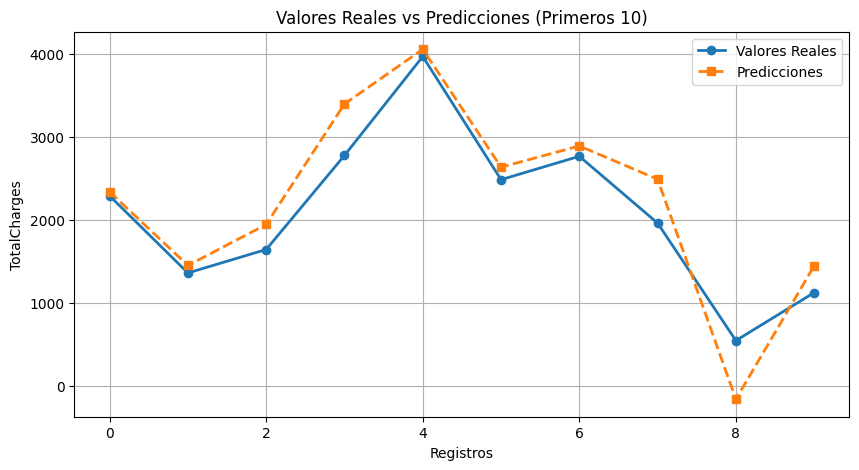

In [57]:
comparacion_10 = comparacion.head(10)
plt.figure(figsize=(10, 5))
# Valores reales
plt.plot(
    comparacion_10["Valor Real"],
    marker="o",
    linewidth=2,
    label="Valores Reales"
)
# Valores predichos
plt.plot(
    comparacion_10["Predicción"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Predicciones"
)
plt.title("Valores Reales vs Predicciones (Primeros 10)")
plt.xlabel("Registros")
plt.ylabel("TotalCharges")
plt.legend()
plt.grid(True)
plt.show()

## 🧮 10. Evaluación del modelo
Calculamos las métricas de desempeño del modelo: MAE, MSE, RMSE y R2, e interpretamos el resultado.

In [58]:
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predicciones)

mostrar_titulo("Métricas del modelo", "🧮")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

# Interpretación automática MAE
if mae < 1:
    display(Markdown("🟢 **MAE:** Precisión MUY ALTA."))
elif mae < 5:
    display(Markdown("🟡 **MAE:** Buena precisión predictiva."))
elif mae < 10:
    display(Markdown("🟠 **MAE:** Precisión aceptable."))
else:
    display(Markdown("🔴 **MAE:** Errores elevados, requiere mejoras."))

# Interpretación automática MSE
if mse < 1:
    display(Markdown("🟢 **MSE:** Desempeño EXCELENTE."))
elif mse < 10:
    display(Markdown("🟡 **MSE:** Buen nivel de precisión."))
elif mse < 50:
    display(Markdown("🟠 **MSE:** Precisión aceptable."))
else:
    display(Markdown("🔴 **MSE:** Errores elevados, requiere optimización."))

# Interpretación automática RMSE
if rmse < 1:
    display(Markdown("🟢 **RMSE:** Desempeño EXCELENTE."))
elif rmse < 5:
    display(Markdown("🟡 **RMSE:** Muy buena precisión."))
elif rmse < 10:
    display(Markdown("🟠 **RMSE:** Precisión aceptable."))
else:
    display(Markdown("🔴 **RMSE:** Requiere mejoras."))

# Interpretación automática R2
porcentaje = r2 * 100
if r2 >= 0.90:
    display(Markdown(f"🟢 **R²:** Ajuste EXCELENTE. Explica el {porcentaje:.2f}% de la variabilidad."))
elif r2 >= 0.75:
    display(Markdown(f"🟡 **R²:** Muy buen desempeño. Explica el {porcentaje:.2f}% de la variabilidad."))
elif r2 >= 0.50:
    display(Markdown(f"🟠 **R²:** Desempeño aceptable. Explica el {porcentaje:.2f}% de la variabilidad."))
elif r2 >= 0:
    display(Markdown(f"🔴 **R²:** Baja capacidad predictiva. Explica solo el {porcentaje:.2f}% de la variabilidad."))
else:
    display(Markdown("🔴 **R²:** El modelo es deficiente y requiere mejoras."))

mostrar_titulo("¿Qué significa cada métrica?", "ℹ️")
display(Markdown(
    "- **MAE**: Error absoluto medio, promedio de la diferencia absoluta entre valores reales y predichos.\n"
    "- **MSE**: Error cuadrático medio, promedio de los errores al cuadrado.\n"
    "- **RMSE**: Raíz cuadrada del MSE, error promedio en las mismas unidades que la variable objetivo.\n"
    "- **R²**: Proporción de la varianza explicada por el modelo (1 es perfecto, 0 es nulo)."
))


### 🧮 Métricas del modelo

MAE : 334.9507
MSE : 192838.9797
RMSE: 439.1344
R2  : 0.9306


🔴 **MAE:** Errores elevados, requiere mejoras.

🔴 **MSE:** Errores elevados, requiere optimización.

🔴 **RMSE:** Requiere mejoras.

🟢 **R²:** Ajuste EXCELENTE. Explica el 93.06% de la variabilidad.


### ℹ️ ¿Qué significa cada métrica?

- **MAE**: Error absoluto medio, promedio de la diferencia absoluta entre valores reales y predichos.
- **MSE**: Error cuadrático medio, promedio de los errores al cuadrado.
- **RMSE**: Raíz cuadrada del MSE, error promedio en las mismas unidades que la variable objetivo.
- **R²**: Proporción de la varianza explicada por el modelo (1 es perfecto, 0 es nulo).

## 📊 11. Visualización de Resultados
Visualizamos la relación entre los valores reales y las predicciones del modelo con un gráfico de dispersión.

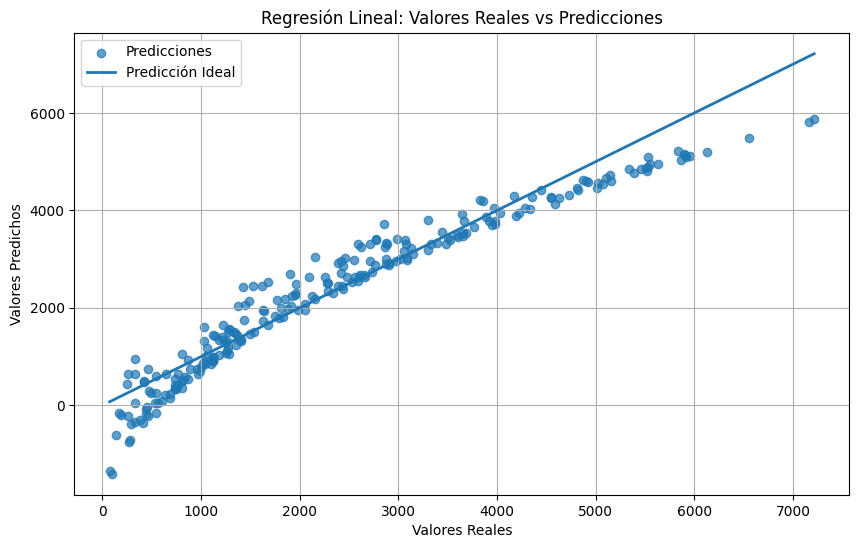

✅ **Interpretación:** El gráfico evidencia un ajuste **EXCELENTE** del modelo.

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, predicciones, alpha=0.7, label="Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, label="Predicción Ideal")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Regresión Lineal: Valores Reales vs Predicciones")
plt.legend()
plt.grid(True)
plt.show()

# Interpretación automática basada en R²
if r2 >= 0.90:
    display(Markdown("✅ **Interpretación:** El gráfico evidencia un ajuste **EXCELENTE** del modelo."))
elif r2 >= 0.75:
    display(Markdown("🟢 **Interpretación:** El modelo presenta muy buena relación entre valores reales y predichos."))
elif r2 >= 0.50:
    display(Markdown("🟡 **Interpretación:** El modelo posee una precisión aceptable."))
else:
    display(Markdown("🔴 **Interpretación:** El modelo presenta baja precisión predictiva."))

## 🧑‍💻 12. Predicción para un nuevo cliente
Ejemplo de predicción usando el modelo entrenado para un cliente hipotético.

In [60]:
# Datos de un nuevo cliente (ejemplo)
nuevo_cliente = pd.DataFrame({
    "tenure": [24],
    "MonthlyCharges": [85],
    "Contract": [1],
    "InternetService": [0]
})
mostrar_titulo("Datos del nuevo cliente", "🧑‍💻")
display(nuevo_cliente)

# Normalización	nuevo_cliente_normalizado = scaler.transform(nuevo_cliente)
# Predicción
nuevo_cliente_normalizado = scaler.transform(nuevo_cliente)
prediccion = modelo.predict(nuevo_cliente_normalizado)
mostrar_titulo("Resultado de la predicción", "🔮")
print(f"TotalCharges estimado: {prediccion[0]:.2f}")

# Interpretación automática
if prediccion[0] < 100:
    display(Markdown("🟢 **Interpretación:** El cliente presenta un TotalCharges bajo."))
elif prediccion[0] < 500:
    display(Markdown("🟡 **Interpretación:** El cliente presenta un TotalCharges moderado."))
else:
    display(Markdown("🔴 **Interpretación:** El cliente presenta un TotalCharges elevado."))


### 🧑‍💻 Datos del nuevo cliente

,tenure,MonthlyCharges,Contract,InternetService
0,24,85,1,0



### 🔮 Resultado de la predicción

TotalCharges estimado: 2290.83


🔴 **Interpretación:** El cliente presenta un TotalCharges elevado.

## 🏆 13. Optimización del modelo con GridSearchCV
En esta etapa optimizamos un modelo de Random Forest usando búsqueda de hiperparámetros con validación cruzada.

### 🎯 Objetivo
Encontrar la combinación de parámetros que maximiza el desempeño predictivo (R²) y comparar el resultado con el modelo base.

In [65]:
# OPTIMIZACIÓN DE MODELO MACHINE LEARNING
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

mostrar_titulo("Paso 1-4: Preparación de datos", "🧩")
X_opt = datos[["tenure", "MonthlyCharges", "Contract", "InternetService"]]
y_opt = datos["TotalCharges"]

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("📌 VARIABLES SELECCIONADAS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
print(X_opt.head())

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt,
    y_opt,
    test_size=0.2,
    random_state=42
)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("✂️ DATOS DIVIDIDOS CORRECTAMENTE")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
print("X_train:", X_train_opt.shape)
print("X_test :", X_test_opt.shape)

scaler_opt = StandardScaler()
X_train_opt = scaler_opt.fit_transform(X_train_opt)
X_test_opt = scaler_opt.transform(X_test_opt)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("📏 DATOS NORMALIZADOS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

mostrar_titulo("Paso 5-7: Modelo base y GridSearchCV", "⚙️")
modelo_rf = RandomForestRegressor(random_state=42)
print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("🤖 MODELO BASE CREADO")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

parametros = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("🧪 HIPERPARÁMETROS DEFINIDOS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
print(parametros)

grid = GridSearchCV(
    estimator=modelo_rf,
    param_grid=parametros,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

display(Markdown("📌 GridSearchCV configurado. Iniciando entrenamiento..."))

mostrar_titulo("Paso 8-11: Entrenamiento y predicciones", "🚀")
grid.fit(X_train_opt, y_train_opt)
mejor_modelo = grid.best_estimator_
predicciones_opt = mejor_modelo.predict(X_test_opt)

display(Markdown("✅ Optimización finalizada y predicciones generadas."))

mostrar_titulo("Paso 12: Métricas del modelo optimizado", "📊")
mae_opt = mean_absolute_error(y_test_opt, predicciones_opt)
mse_opt = mean_squared_error(y_test_opt, predicciones_opt)
rmse_opt = np.sqrt(mse_opt)
r2_opt = r2_score(y_test_opt, predicciones_opt)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("📈 MÉTRICAS DEL MODELO OPTIMIZADO")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
print(f"MAE  : {mae_opt:.4f}")
print(f"MSE  : {mse_opt:.4f}")
print(f"RMSE : {rmse_opt:.4f}")
print(f"R²   : {r2_opt:.4f}")

metricas_opt = pd.DataFrame(
    {
        "Métrica": ["MAE", "MSE", "RMSE", "R²"],
        "Valor": [mae_opt, mse_opt, rmse_opt, r2_opt]
    }
)
display(metricas_opt)

mostrar_titulo("Paso 13: Interpretación automática", "🧠")
print(
    f"\nEl modelo obtuvo un R² de {r2_opt:.4f}, "
    "lo que representa su capacidad para explicar la variabilidad de los datos."
)
print(
    f"\nEl RMSE obtenido fue de {rmse_opt:.4f}, "
    "indicando el nivel promedio de error en las predicciones."
)

if r2_opt >= 0.90:
    display(Markdown("🟢 **El modelo optimizado posee un desempeño EXCELENTE.**"))
elif r2_opt >= 0.75:
    display(Markdown("🟡 **El modelo optimizado presenta muy buena precisión.**"))
elif r2_opt >= 0.50:
    display(Markdown("🟠 **El modelo optimizado posee desempeño aceptable.**"))
else:
    display(Markdown("🔴 **El modelo requiere mejoras adicionales.**"))

mostrar_titulo("Mejores hiperparámetros encontrados", "🏅")
display(pd.DataFrame([grid.best_params_]))


### 🧩 Paso 1-4: Preparación de datos


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 VARIABLES SELECCIONADAS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   tenure  MonthlyCharges  Contract  InternetService
0       4           34.69         2                1
1      55           56.56         0                0
2      70           56.95         1                0
3      55           39.33         1                1
4      49          109.32         0                1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✂️ DATOS DIVIDIDOS CORRECTAMENTE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

X_train: (960, 4)
X_test : (240, 4)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📏 DATOS NORMALIZADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━




### ⚙️ Paso 5-7: Modelo base y GridSearchCV


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🤖 MODELO BASE CREADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🧪 HIPERPARÁMETROS DEFINIDOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


📌 GridSearchCV configurado. Iniciando entrenamiento...

...


### 🧠 Paso 13: Interpretación automática


El modelo obtuvo un R² de 0.9979, lo que representa su capacidad para explicar la variabilidad de los datos.

El RMSE obtenido fue de 76.1442, indicando el nivel promedio de error en las predicciones.


🟢 **El modelo optimizado posee un desempeño EXCELENTE.**


### 🏅 Mejores hiperparámetros encontrados

,max_depth,min_samples_leaf,min_samples_split,n_estimators
0,10,1,2,50


## 🧩 14. Matriz de confusión para regresión discretizada
Para visualizar mejor el comportamiento del modelo en rangos de valores, convertimos la regresión en categorías (cuartiles) y mostramos una matriz de confusión mejorada.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🧮 MATRIZ DE CONFUSIÓN (REGRESIÓN DISCRETIZADA)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



,Pred Q1,Pred Q2,Pred Q3,Pred Q4
Real Q1,59,1,0,0
Real Q2,1,58,1,0
Real Q3,0,1,58,1
Real Q4,0,0,1,59


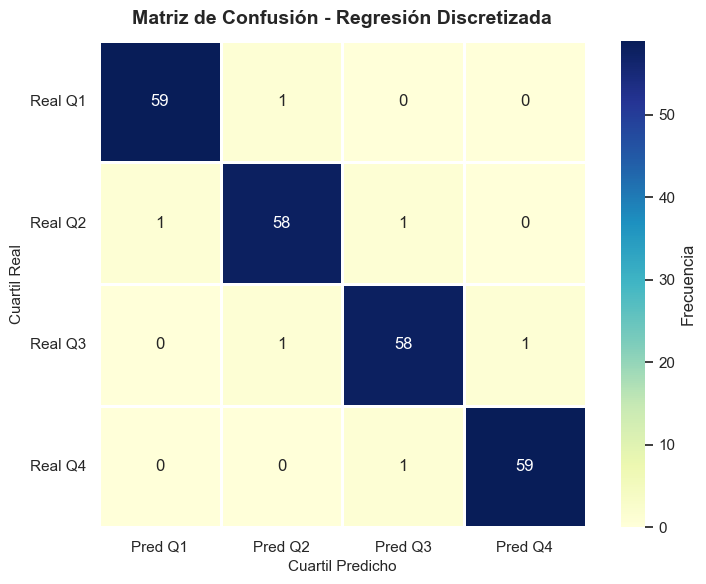

📌 **Coincidencia en la diagonal principal:** 234/240 (97.50%).

In [67]:
# Matriz de confusión para regresión (con discretización en cuartiles)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Discretizar valores reales y predichos en categorías (cuartiles)
real_categorias = pd.qcut(y_test, q=4, labels=["Q1", "Q2", "Q3", "Q4"])
pred_categorias = pd.qcut(predicciones, q=4, labels=["Q1", "Q2", "Q3", "Q4"])

matriz_confusion = confusion_matrix(real_categorias, pred_categorias, labels=["Q1", "Q2", "Q3", "Q4"])

matriz_df = pd.DataFrame(
    matriz_confusion,
    index=["Real Q1", "Real Q2", "Real Q3", "Real Q4"],
    columns=["Pred Q1", "Pred Q2", "Pred Q3", "Pred Q4"]
)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("🧮 MATRIZ DE CONFUSIÓN (REGRESIÓN DISCRETIZADA)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")
display(matriz_df)

# Estilo visual mejorado
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    matriz_df,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Frecuencia"},
    square=True
)

ax.set_title("Matriz de Confusión - Regresión Discretizada", fontsize=14, pad=12, fontweight="bold")
ax.set_xlabel("Cuartil Predicho", fontsize=11)
ax.set_ylabel("Cuartil Real", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Breve interpretación automática
aciertos_diagonal = matriz_df.values.diagonal().sum()
total_casos = matriz_df.values.sum()
precision_discretizada = aciertos_diagonal / total_casos
display(Markdown(
    f"📌 **Coincidencia en la diagonal principal:** {aciertos_diagonal}/{total_casos} "
    f"({precision_discretizada:.2%})."
))

Durante la Semana 3, aprendimos a desarrollar un flujo completo de regresión lineal para estimar el valor de TotalCharges en clientes de telecomunicaciones, integrando etapas de análisis, preparación, modelado y evaluación. Iniciamos con la importación de librerías y la carga del dataset, seguida de una exploración inicial para comprender su estructura, tipos de datos, estadísticas y posibles valores nulos.

Posteriormente, realizamos el preprocesamiento de datos, que incluyó la conversión de variables al formato adecuado, la eliminación de registros nulos y duplicados, y la codificación de variables categóricas para su uso en modelos de machine learning. Luego, definimos las variables predictoras y la variable objetivo, dividimos los datos en entrenamiento y prueba, y aplicamos normalización para mejorar la estabilidad del modelo.

En la etapa de modelado, entrenamos un modelo de regresión lineal, generamos predicciones y comparamos los resultados reales frente a los estimados mediante tablas y gráficos. Después, evaluamos su desempeño utilizando métricas clave como MAE, MSE, RMSE y R², incorporando interpretaciones automáticas que facilitaron la comprensión de la calidad predictiva del modelo.

Finalmente, fortalecimos el análisis con una predicción para un nuevo cliente, una optimización del modelo mediante GridSearchCV con Random Forest y una matriz de confusión para regresión discretizada en cuartiles. Todo este proceso nos permitió consolidar una visión integral del aprendizaje supervisado en problemas de regresión, comprendiendo no solo cómo construir modelos, sino también cómo interpretarlos, mejorarlos y comunicar sus resultados de forma clara y aplicada.